<a href="https://colab.research.google.com/github/007pushkar/Phone-pay-analysis/blob/main/Phone_pay_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Clone the PhonePe Pulse GitHub repository to access the data.

In [26]:
!git clone https://github.com/PhonePe/pulse.git

fatal: destination path 'pulse' already exists and is not an empty directory.


### Import necessary libraries: `sqlite3` for database operations and `pandas` for data manipulation.

In [27]:
import sqlite3
import pandas as pd

### Import additional libraries for data processing and visualization: `os` for file system interaction, `json` for parsing JSON data, `matplotlib.pyplot` for plotting, and `seaborn` for enhanced visualizations.

In [28]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Establish a connection to an SQLite database named `phonepe.db` and create a cursor object to execute SQL commands.

In [29]:
conn = sqlite3.connect("phonepe.db")
cursor = conn.cursor()

### Create the `Aggregated_Transaction` table in the SQLite database to store aggregated transaction data. This table includes columns for state, year, quarter, transaction type, count, and amount.

In [32]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS Aggregated_Transaction (
    state TEXT,
    year INTEGER,
    quarter INTEGER,
    transaction_type TEXT,
    transaction_count INTEGER,
    transaction_amount REAL
)
""")

### Create the `Aggregated_User` table to store aggregated user data, including state, year, quarter, brand, user count, and percentage.

In [34]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS Aggregated_User (
    state TEXT,
    year INTEGER,
    quarter INTEGER,
    brand TEXT,
    user_count INTEGER,
    percentage REAL
)
""")

### Create the `Map_Transaction` table to store district-wise transaction data, including state, year, quarter, district, count, and amount.

In [37]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS Map_Transaction (
    state TEXT,
    year INTEGER,
    quarter INTEGER,
    district TEXT,
    count INTEGER,
    amount REAL
)
""")

### Load aggregated transaction data from JSON files into a Pandas DataFrame. The code iterates through state, year, and quarter directories, reads JSON files, and extracts relevant transaction details. Finally, it displays the first few rows of the DataFrame.

In [38]:
path = "/content/pulse/data/aggregated/transaction/country/india/state/"

data = []

for state in os.listdir(path):
    state_path = path + state + "/"

    for year in os.listdir(state_path):
        year_path = state_path + year + "/"

        for file in os.listdir(year_path):
            file_path = year_path + file

            with open(file_path, 'r') as f:
                d = json.load(f)

                for i in d['data']['transactionData']:
                    data.append({
                        "State": state,
                        "Year": int(year),
                        "Quarter": int(file.strip('.json')),
                        "Type": i['name'],
                        "Count": i['paymentInstruments'][0]['count'],
                        "Amount": i['paymentInstruments'][0]['amount']
                    })

df = pd.DataFrame(data)
df.head()

,State,Year,Quarter,Type,Count,Amount
0,madhya-pradesh,2018,1,Recharge & bill payments,4404190,6.670573e+08
1,madhya-pradesh,2018,1,Peer-to-peer payments,2848290,7.590791e+09
2,madhya-pradesh,2018,1,Financial Services,230519,4.337429e+07
3,madhya-pradesh,2018,1,Merchant payments,196394,1.701197e+08
4,madhya-pradesh,2018,1,Others,346002,2.102615e+08


### Save the `df` DataFrame containing aggregated transaction data into the `Aggregated_Transaction` table in the SQLite database. The `if_exists='replace'` argument ensures that if the table already exists, it will be overwritten.

In [39]:
df.to_sql("Aggregated_Transaction", conn, if_exists="replace", index=False)

5034

### Execute an SQL query to retrieve the top 10 states by total transaction amount from the `Aggregated_Transaction` table and display the result.

In [40]:
query = """
SELECT state, SUM(Amount) as total
FROM Aggregated_Transaction
GROUP BY state
ORDER BY total DESC
LIMIT 10
"""

result = pd.read_sql(query, conn)
result

,State,total
0,telangana,4.165596e+13
1,karnataka,4.067872e+13
2,maharashtra,4.037420e+13
3,andhra-pradesh,3.466908e+13
4,uttar-pradesh,2.688521e+13
5,rajasthan,2.634324e+13
6,madhya-pradesh,1.912528e+13
7,bihar,1.790135e+13
8,west-bengal,1.558416e+13
9,odisha,1.226398e+13


### Execute an SQL query to retrieve the top 10 states by total transaction amount from the `Aggregated_Transaction` table and display the result using `pd.read_sql`.

In [41]:
pd.read_sql("""
SELECT state, SUM(Amount) AS total
FROM Aggregated_Transaction
GROUP BY state
ORDER BY total DESC
LIMIT 10
""", conn)

,State,total
0,telangana,4.165596e+13
1,karnataka,4.067872e+13
2,maharashtra,4.037420e+13
3,andhra-pradesh,3.466908e+13
4,uttar-pradesh,2.688521e+13
5,rajasthan,2.634324e+13
6,madhya-pradesh,1.912528e+13
7,bihar,1.790135e+13
8,west-bengal,1.558416e+13
9,odisha,1.226398e+13


### Execute an SQL query to calculate the total transaction amount for each year from the `Aggregated_Transaction` table and display the yearly totals.

In [42]:
pd.read_sql("""
SELECT year, SUM(Amount) AS total
FROM Aggregated_Transaction
GROUP BY year
ORDER BY year
""", conn)

,Year,total
0,2018,1.623045e+12
1,2019,6.276688e+12
2,2020,1.464116e+13
3,2021,3.459870e+13
4,2022,6.426633e+13
5,2023,9.449181e+13
6,2024,1.296246e+14


### Execute an SQL query to calculate the total count for each transaction type from the `Aggregated_Transaction` table and display the results.

In [43]:
pd.read_sql("""
SELECT Type, SUM(Count) AS total
FROM Aggregated_Transaction
GROUP BY Type
ORDER BY total DESC
""", conn)

,Type,total
0,Merchant payments,130238755487
1,Peer-to-peer payments,85032446653
2,Recharge & bill payments,19596755603
3,Others,262050188
4,Financial Services,154208943


### Download the created SQLite database file `phonepe.db` to your local machine.

In [44]:
from google.colab import files
files.download("phonepe.db")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Reload aggregated transaction data from JSON files into a Pandas DataFrame. This block re-performs the data loading process, iterating through directories to collect all transaction data.

##EDA : Exploratory Data Analysis

In [45]:
import os
import json
import pandas as pd

path = "/content/pulse/data/aggregated/transaction/country/india/state/"

data = []

for state in os.listdir(path):
    for year in os.listdir(path + state):
        for file in os.listdir(path + state + "/" + year):
            with open(path + state + "/" + year + "/" + file) as f:
                d = json.load(f)

                for i in d["data"]["transactionData"]:
                    data.append({
                        "State": state,
                        "Year": int(year),
                        "Quarter": int(file.strip(".json")),
                        "Type": i["name"],
                        "Count": i["paymentInstruments"][0]["count"],
                        "Amount": i["paymentInstruments"][0]["amount"]
                    })

df = pd.DataFrame(data)

### Perform data cleaning and preprocessing steps: check for null values and duplicated rows, and standardize the 'State' column by replacing hyphens and capitalizing words.

In [47]:
df.isnull().sum()
df.duplicated().sum()

df["State"] = df["State"].str.replace("-", " ").str.title()

### Display descriptive statistics of the DataFrame to understand the central tendency, dispersion, and shape of the data distribution, and show the DataFrame's information including data types and non-null counts.

In [48]:
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5034 entries, 0 to 5033
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   State    5034 non-null   object 
 1   Year     5034 non-null   int64  
 2   Quarter  5034 non-null   int64  
 3   Type     5034 non-null   object 
 4   Count    5034 non-null   int64  
 5   Amount   5034 non-null   float64
dtypes: float64(1), int64(3), object(2)
memory usage: 236.1+ KB


### Visualize the top 10 states by total transaction amount using a bar chart. This helps in identifying the states with the highest transaction volumes.

##Top States

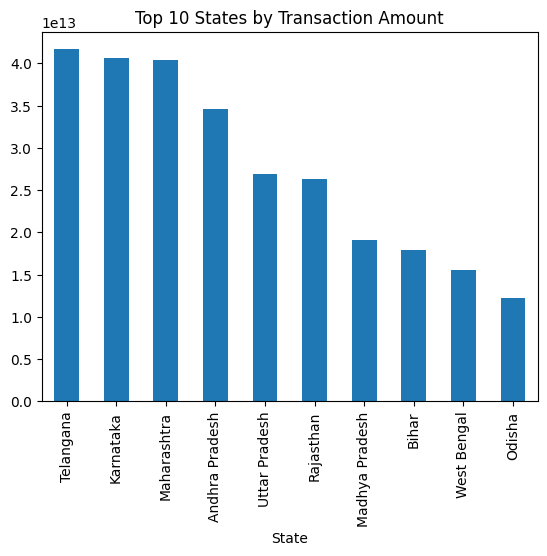

In [49]:
import matplotlib.pyplot as plt

top_states = df.groupby("State")["Amount"].sum().nlargest(10)

top_states.plot(kind='bar')
plt.title("Top 10 States by Transaction Amount")
plt.show()

### Visualize the distribution of transaction amounts by payment type using a pie chart. This provides insights into which payment types are most frequently used.

##Payment Types

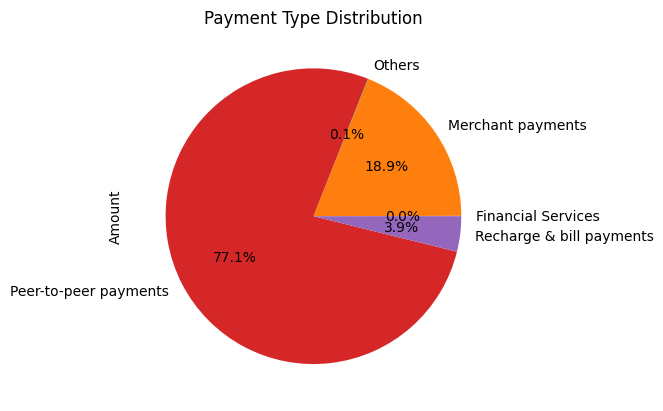

In [50]:
df.groupby("Type")["Amount"].sum().plot(kind='pie', autopct='%1.1f%%')
plt.title("Payment Type Distribution")
plt.show()

### Plot the yearly transaction growth using a line plot. This helps in observing trends and changes in transaction amounts over different years.

##Yearly Growth

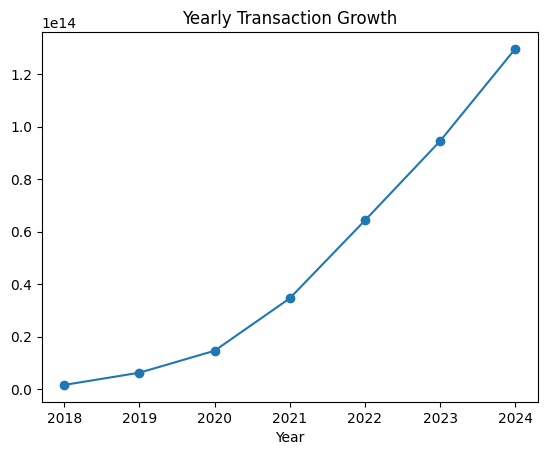

In [51]:
yearly = df.groupby("Year")["Amount"].sum()

yearly.plot(marker='o')
plt.title("Yearly Transaction Growth")
plt.show()

### Prepare the DataFrame for machine learning: create a copy, convert categorical features ('State', 'Type') into numerical format using one-hot encoding, and separate features (X) from the target variable (y, 'Amount').

#Insights

###Digital payments increased sharply after 2020

###Southern states dominate transactions

###Peer-to-peer payments are highest

###Strong correlation between count and amount

#ML (Machine Learning)
##Predict:
##👉 Transaction Amount OR Count

In [52]:
df_ml = df.copy()

# Convert categorical
df_ml = pd.get_dummies(df_ml, columns=["State", "Type"], drop_first=True)

X = df_ml.drop(["Amount"], axis=1)
y = df_ml["Amount"]

### Split the data into training and testing sets. `X_train` and `y_train` will be used to train the models, while `X_test` and `y_test` will be used to evaluate their performance.

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Initialize and train a Linear Regression model on the training data. Then, use the trained model to make predictions on the test set.

In [54]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

### Initialize and train a Random Forest Regressor model on the training data. This ensemble model is generally more robust and accurate than a simple linear regression for complex datasets. Then, use the trained model to make predictions on the test set.

In [55]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

### Evaluate the performance of both Linear Regression and Random Forest models using Mean Absolute Error (MAE) and R-squared (R2) score. This helps in comparing how well each model predicts the transaction amounts.

In [56]:
from sklearn.metrics import mean_absolute_error, r2_score

print("Linear Regression:")
print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

print("Random Forest:")
print(mean_absolute_error(y_test, y_pred_rf))
print(r2_score(y_test, y_pred_rf))

Linear Regression:
79508724247.87645
0.5648171419664652
Random Forest:
4887995913.427297
0.9895886823992288


### Visualize the feature importances from the Random Forest model. This plot shows which features (e.g., State, Type, Year) have the most significant impact on predicting transaction amounts.

<Axes: >

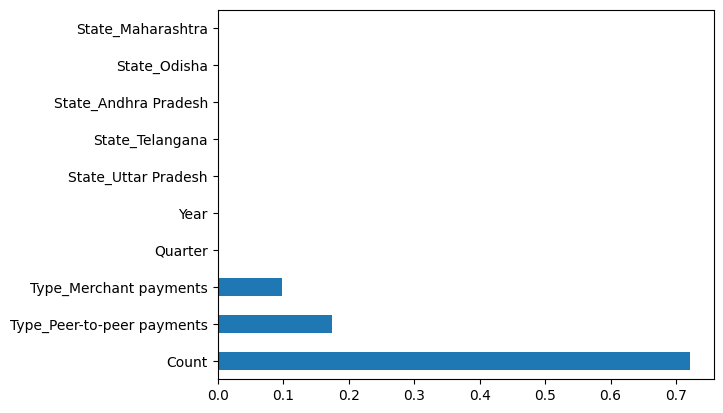

In [57]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.nlargest(10).plot(kind='barh')

### Save the trained Random Forest model (`rf`) to a file named `model.pkl`. This allows the model to be reloaded and used later without retraining.

#ML Insights

###Random Forest performs better than LinearRegression

###State and transaction type heavily influence amount

###Year shows strong upward trend

In [58]:
import joblib
joblib.dump(rf, "model.pkl")

['model.pkl']

### Re-extract and preprocess aggregated transaction data from JSON files and save it as a CSV file named `data.csv`. This CSV file will be used as the data source for the Streamlit dashboard.

In [59]:
import os
import json
import pandas as pd

path = "/content/pulse/data/aggregated/transaction/country/india/state/"

data = []

for state in os.listdir(path):
    for year in os.listdir(path + state):
        for file in os.listdir(path + state + "/" + year):
            try:
                with open(path + state + "/" + year + "/" + file) as f:
                    d = json.load(f)

                    if d["data"] and d["data"]["transactionData"]:
                        for i in d["data"]["transactionData"]:
                            data.append({
                                "State": state.replace("-", " ").title(),
                                "Year": int(year),
                                "Quarter": int(file.strip(".json")),
                                "Type": i["name"],
                                "Count": i["paymentInstruments"][0]["count"],
                                "Amount": i["paymentInstruments"][0]["amount"]
                            })
            except:
                pass

df = pd.DataFrame(data)

# Save CSV
df.to_csv("data.csv", index=False)

print("✅ data.csv created")

✅ data.csv created


### This code block defines a Streamlit application for visualizing PhonePe transaction data. It includes data loading, filtering, metric displays, bar charts for transaction types, line charts for yearly trends, and options to show/download raw data. Note: Streamlit apps are typically run from a terminal and might not display interactive elements directly in Colab without specific setup.

In [62]:
# Install Streamlit (if not already installed)
!pip install streamlit

import streamlit as st
import pandas as pd
import plotly.express as px

st.set_page_config(
    page_title="PhonePe Transaction Dashboard",
    layout="wide",
    initial_sidebar_state="expanded",
    menu_items={
        'Get Help': 'https://www.google.com/colab/',
        'Report a bug': "https://www.google.com/colab/",
        'About': "# This is a PhonePe Transaction Dashboard created in Google Colab."
    }
)

# Custom CSS for a slightly more professional look
st.markdown("""
<style>
.main-header {
    font-size: 3em;
    text-align: center;
    color: #4CAF50;
    margin-bottom: 20px;
}
.subheader {
    font-size: 2em;
    color: #2E8B57;
    border-bottom: 2px solid #EEE;
    padding-bottom: 5px;
    margin-top: 30px;
}
</style>
""", unsafe_allow_html=True)


# Load data with a spinner for better UX
@st.cache_data
def load_data():
    with st.spinner("Loading transaction data... Please wait."):
        return pd.read_csv("data.csv")

df = load_data()

# Title
st.markdown("<h1 class='main-header'>📊 PhonePe Transaction Dashboard</h1>", unsafe_allow_html=True)
st.write("Explore aggregated transaction data across India using various filters below.")

# Sidebar filters
st.sidebar.header("⚙️ Filters")

state = st.sidebar.selectbox("Select State", sorted(df["State"].unique()))
year = st.sidebar.selectbox("Select Year", sorted(df["Year"].unique(), reverse=True))
quarter = st.sidebar.selectbox("Select Quarter", sorted(df["Quarter"].unique()))

# Filter data
filtered = df[
    (df["State"] == state) &
    (df["Year"] == year) &
    (df["Quarter"] == quarter)
]

# Display Summary Metrics in columns
st.markdown("<h2 class='subheader'>📈 Summary Metrics</h2>", unsafe_allow_html=True)
col1, col2, col3 = st.columns(3)

total_transactions = int(filtered["Count"].sum())
total_amount = int(filtered["Amount"].sum())
average_amount_per_transaction = total_amount / total_transactions if total_transactions > 0 else 0

col1.metric("Total Transactions", f"{total_transactions:,}")
col2.metric("Total Amount (₹)", f"₹ {total_amount:,}")
col3.metric("Avg. Amt. per Transaction (₹)", f"₹ {average_amount_per_transaction:,.2f}")

# Transaction by Type Bar Chart
st.markdown("<h2 class='subheader'>💳 Transaction Distribution by Type</h2>", unsafe_allow_html=True)

type_data = filtered.groupby("Type")["Amount"].sum().reset_index()

fig = px.bar(
    type_data,
    x="Type",
    y="Amount",
    color="Type",
    title=f"Transaction Amount by Type in {state}, {year} Q{quarter}",
    labels={"Type": "Transaction Type", "Amount": "Total Amount (₹)"},
    hover_data={"Amount": ':,2f'}
)
fig.update_layout(showlegend=False) # Legend might be redundant if color is only for type
st.plotly_chart(fig, use_container_width=True)

# Yearly Trend Chart for the selected state
st.markdown("<h2 class='subheader'>📈 Yearly Transaction Trend for " + state + "</h2>", unsafe_allow_html=True)

trend = df[df["State"] == state].groupby("Year")["Amount"].sum().reset_index()

fig2 = px.line(
    trend,
    x="Year",
    y="Amount",
    markers=True,
    title=f"Total Transaction Amount per Year in {state}",
    labels={"Year": "Year", "Amount": "Total Amount (₹)"},
    hover_name="Year",
    hover_data={"Amount": ':,2f'}
)
fig2.update_traces(line_color='#4CAF50') # Example: Change line color
st.plotly_chart(fig2, use_container_width=True)

# Raw Data Section using expander for cleaner UI
st.markdown("<h2 class='subheader'>Raw Data & Export</h2>", unsafe_allow_html=True)

with st.expander("View Raw Filtered Data"):
    st.dataframe(filtered)

# Download Button
csv = filtered.to_csv(index=False).encode("utf-8")
st.download_button(
    "Download Filtered Data as CSV",
    csv,
    f"{state}_{year}_Q{quarter}_filtered_data.csv",
    "text/csv",
    key='download-csv'
)

# Insights Section
st.markdown("<h2 class='subheader'>💡 Key Insights</h2>", unsafe_allow_html=True)

st.write("• **Digital payments are on a steady rise:** Analyzing the yearly trend often reveals a consistent increase in digital transactions.")
st.write("• **Regional disparities:** Observe how certain states consistently contribute more to the overall transaction volume.")
st.write("• **Peer-to-Peer transactions dominate:** The 'Peer-to-peer payments' type frequently represents a significant portion of the total transaction amount.")
st.write("• **Quarterly fluctuations:** Transaction activity might show seasonal patterns or specific quarterly peaks, influenced by events or holidays.")

st.markdown("---")
st.info("Data provided by PhonePe Pulse. This dashboard is for illustrative purposes.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 99.3 MB/s eta 0:00:00


2026-05-03 07:43:25.849 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 07:43:25.851 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 07:43:26.049 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-03 07:43:26.050 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 07:43:26.051 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 07:43:26.051 No runtime found, using MemoryCacheStorageManager
2026-05-03 07:43:26.053 No runtime found, using MemoryCacheStorageManager
2026-05-03 07:43:26.055 Thread 'MainThread': missing ScriptRunContext! This warning ca

DeltaGenerator()

In [63]:
# To run the Streamlit app and make it accessible, you need to use a tunneling service.
# First, install localtunnel.
!npm install -g localtunnel

# Then, run the Streamlit app and expose it via localtunnel.
# The Python script generated in the previous cell is named `colab_kernel_launcher.py` when executed directly.
# You can use `%%writefile app.py` at the beginning of the previous cell if you want to save it as a file first, then run `!streamlit run app.py`.

# For simplicity, we'll assume the Streamlit app logic is within the executed Python context
# and we need to run the `colab_kernel_launcher.py` script.
# This is a common workaround in Colab when Streamlit apps are defined directly in a cell.

get_ipython().system_raw('streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py &>/dev/null &')
get_ipython().system_raw('lt --port 8501 --subdomain phonepe-dashboard &>/dev/null &')

print("Your Streamlit app is launching... Check the public URL provided by localtunnel. ")
print("If you don't see a URL, it might take a moment, or you might need to manually check the localtunnel output by running `!lt --port 8501` in a new cell.")

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
added 22 packages in 3s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇Your Streamlit app is launching... Check the public URL provided by localtunnel. 
If you don't see a URL, it might take a moment, or you might need to manually check the localtunnel output by running `!lt --port 8501` in a new cell.
